
# Mean Shift Clustering
###
#### Tiago Gunter
#### Walker Department of Mechanical Engineering, Cockrell School of Engineering
###
### Subsurface Machine Learning Course, The University of Texas at Austin
#### Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering
#### Department of Geological Sciences, Jackson School of Geosciences

_____________________

Workflow supervision and review by:

#### Instructor: Prof. Michael Pyrcz, Ph.D., P.Eng., Associate Professor, The Univeristy of Texas at Austin
[Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Geostatistics Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [Applied Machine Learning in Python e-book](https://geostatsguy.github.io/MachineLearningDemos_Book/) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)

#### Course TA: Elnara Rustamzade, Graduate Student, The University of Texas at Austin
##### [LinkedIn](https://www.linkedin.com/in/elnara-rustamzade/)


### Executive Summary

### 
When analyzing data to find clusters, we are often naive about the number of clusters in the data set. In these circumstances, Mean Shift Clustering is a powerful, non-parametric tool that is able to find clusters in data without previous knowledge of the number of clusters by assigning the data points to the clusters iteratively by shifting points towards the mode. This Jupyter notebook explores how to use Mean Shift Clustering with a data set with an unknown number of clusters. Here we learn how to use this algorithm and verify it with a known data set of three clusters.

**Note:** We will be using Dr. Pyrcz's data which we know has three clusters. The algorithm will not be given this information, but we can use it to check the results. 


### Import Packages

Let's begin by importing the necessary packages.
* Numpy will assist us in creating our arrays
* Pandas will allow us to tabulate our data
* Scikit learn includes the Mean Shift method
* Matplotlib allows us to visualize our data and results



In [12]:
ignore_warnings = True                                        # ignore warnings?
import numpy as np                                            # ndarrays for gridded data
import pandas as pd                                           # DataFrames for tabular data
from sklearn.cluster import MeanShift, estimate_bandwidth


import matplotlib.pyplot as plt                               # for plotting

### Load Data
We will begin by importing the data from Dr. Pyrcz's GeoDataSets GitHub repository.


##### From this data file, we will extract acoustic impedance and porosity (below)
* **porosity** - fraction of rock void in units of percentage
* **acoustic impedence** - product of sonic velocity and rock density in unitsof $kg/m^2s*10^3$


We will also go ahead and normalize the data, and remove the un-normalized data for simplicity.

We will print the data frame that will be used for this workflow


In [13]:
seed = 42 # setting our random seed


# load the comma delimited data file from Dr. Pyrcz's GeoDataSets GitHub repository
df = pd.read_csv('https://raw.githubusercontent.com/GeostatsGuy/GeoDataSets/master/nonlinear_facies_v2.csv ') 
df = df.iloc[:,1:]                                            # remove a null column 

# find min and max for each feature
pormin = df['Por'].min(); pormax = df['Por'].max()  
AImin = df['AI'].min(); AImax = df['AI'].max()

# normalize each feature, this broadcasts over all samples in the DataFrame
df['N_Por'] = (df['Por']-pormin)/(pormax - pormin) 
df['N_AI'] = (df['AI']-AImin)/(AImax - AImin)           

# remove non-normalized Porosity and AI for a simple 2D example
cols_to_drop = ['Por','AI']
df_mod = df.drop(cols_to_drop, axis=1)                             
df_mod
# Lets visualized our dataframe

,Facies,N_Por,N_AI
0,3,0.299356,0.312014
1,3,0.337855,0.247437
2,3,0.538338,0.154292
3,3,0.456550,0.164519
4,3,0.437761,0.236012
...,...,...,...
1795,2,0.343905,0.500859
1796,2,0.579592,0.515370
1797,2,0.457886,0.607492
1798,2,0.517327,0.490913


In [14]:
# Let us also look at the descriptive statistics of our data for reference
df_mod.describe()

,Facies,N_Por,N_AI
count,1800.000000,1800.000000,1800.000000
mean,1.666667,0.570759,0.517246
std,0.816723,0.159290,0.208024
min,1.000000,0.000000,0.000000
25%,1.000000,0.488781,0.426955
50%,1.000000,0.589154,0.566274
75%,2.000000,0.678729,0.649845
max,3.000000,1.000000,1.000000


### Description of Mean shift Clustering
Mean shift clustering is an unsupervised, non-parametric, density-based clustering algorithm that groups points into clusters by finding the modes in the distribution. To accomplish this task, it iteratively shifts data points toward the mean of the points near the data until it converges at a local maximum. This maximum represents the center of a cluster. Unlike k-means clustering, this algorithm automatically determines the number of clusters in the data set. 


### Next, let's plot the raw data for some initial visualization
This will help us have a notion of the expected number of clusters.

**Note:** we will not tell the algorithm how many clusters there are in the data.


Text(0.5, 0, 'Normalized Porosity')

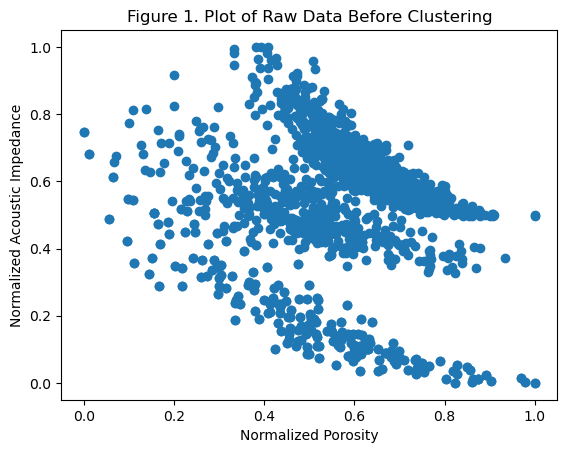

In [15]:
plt.scatter(df_mod["N_Por"], df_mod["N_AI"])
plt.title('Figure 1. Plot of Raw Data Before Clustering')
plt.ylabel('Normalized Acoustic Impedance')
plt.xlabel('Normalized Porosity')

### Next, lets us calculate the number of clusters in the data

In [16]:
# Bandwidth helps us define the size of the neighborhood
bandwidth = estimate_bandwidth(df_mod) 

# Calling the Mean Shift method
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms.fit(df_mod)

# Labeling data per cluster
labels = ms.labels_

labels_unique = np.unique(labels)
n_clusters_ = len(labels_unique)
print("Number of estimated clusters : %d" % n_clusters_)
print()


# Finding the centers of each cluster
cluster_centers = ms.cluster_centers_
print(f'The cluster centers are:')
for i in cluster_centers:
    print (f'{i[1]} , {i[2]}')



Number of estimated clusters : 3

The cluster centers are:
0.6336694408452112 , 0.6451700407295122
0.4901224172624757 , 0.5121211680103258
0.5012700220339249 , 0.19528849191226128


### Now lets plot the raw data with the cluster centers

This will allow us to visualize the location of the cluster centers with regard to the data.

This works as a first visual inspection of the fit of our model

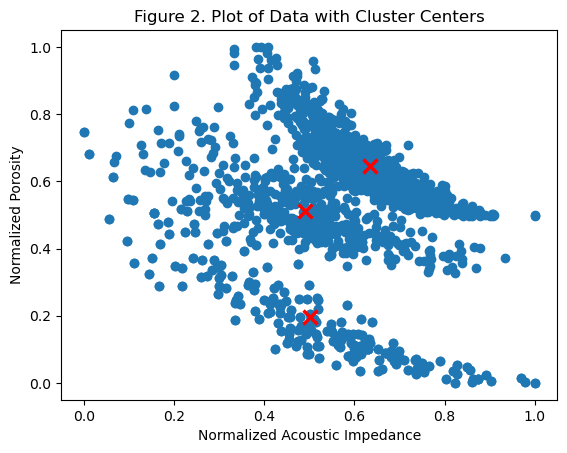

In [17]:
 
# Referenced from https://www.geeksforgeeks.org/machine-learning/ml-mean-shift-clustering/

fig = plt.figure()

ax = fig.add_subplot(111)

ax.scatter(df_mod['N_Por'], df_mod['N_AI'], marker='o')
ax.set_xlabel('Normalized Acoustic Impedance')
ax.set_ylabel('Normalized Porosity')
ax.set_title('Figure 2. Plot of Data with Cluster Centers')


ax.scatter(cluster_centers[:, 1], cluster_centers[:, 2],
           marker='x', color='red',
           s=100, linewidth=2.5, zorder=10)

plt.show()

### Analyze Cluster Centers

From our plot above, we can see that our cluster centers fit our data well. From ocular inspection, they are located at approximately the center of the clusters we know to exist. This suggests a good fit of our model!


### Next, let's plot our data with color coordinated clusters

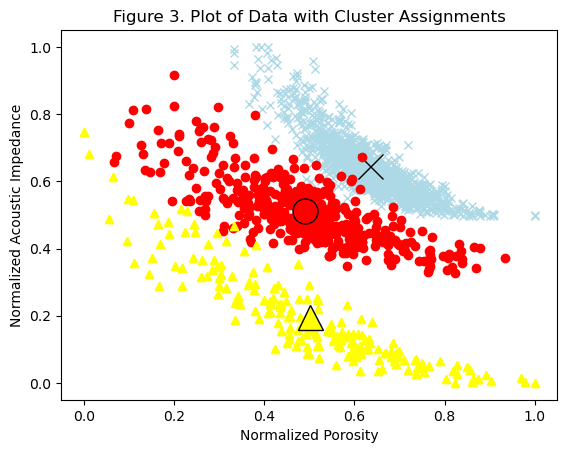

In [18]:

# Referenced from https://scikit-learn.org/stable/auto_examples/cluster/plot_mean_shift.html#generate-sample-data

# Convert DataFrame to numpy array if it's not already
df_mod = df_mod.values if hasattr(df_mod, 'values') else df_mod


plt.figure(1)
plt.clf()

colors = ["lightblue", "red", "yellow"]
markers = ["x", "o", "^"]

for k, col in zip(range(n_clusters_), colors):
    my_members = labels == k
    cluster_center = cluster_centers[k]
    
    plt.plot(df_mod[my_members, 1], df_mod[my_members, 2], markers[k], color=col)
    plt.plot(
        cluster_center[1],
        cluster_center[2],
        markers[k],
        markerfacecolor=col,
        markeredgecolor="k",
        markersize=18,
    )
plt.ylabel('Normalized Acoustic Impedance')
plt.xlabel('Normalized Porosity')
plt.title('Figure 3. Plot of Data with Cluster Assignments')


plt.show()

### Results
As we can see in Figure 3, the data was well sorted into the clusters based on the proximity to the cluster centers. We can identify a few data that were possibly miscategorized, especially a few red data points inside the light blue cluster. However, we can observe the power of this clustering technique. We did not claim there to be three clusters, but the algorithm was able to identify this. We know this dataset to have three clusters from Dr. Pyrcz's previous K-Means clustering workflow. Overall, we illustrated the capabilities of the Mean Shift clustering technique in this workflow, with successful categorization of the data into distinct clusters.


### References
* Dr. Pyrcz's GeoDataSets GitHub repository
* https://www.geeksforgeeks.org/machine-learning/ml-mean-shift-clustering/
* https://scikit-learn.org/stable/auto_examples/cluster/plot_mean_shift.html#generate-sample-data
* Google


#### About the Supervising Professor

Michael Pyrcz is a professor in the [Cockrell School of Engineering](https://cockrell.utexas.edu/faculty-directory/alphabetical/p), and the [Jackson School of Geosciences](https://www.jsg.utexas.edu/researcher/michael_pyrcz/), at [The University of Texas at Austin](https://www.utexas.edu/), where he researches and teaches subsurface, spatial data analytics, geostatistics, and machine learning. Michael is also,

* the principal investigator of the [Energy Analytics](https://fri.cns.utexas.edu/energy-analytics) freshmen research initiative and a core faculty in the Machine Learn Laboratory in the College of Natural Sciences, The University of Texas at Austin

* an associate editor for [Computers and Geosciences](https://www.sciencedirect.com/journal/computers-and-geosciences/about/editorial-board), and a board member for [Mathematical Geosciences](https://link.springer.com/journal/11004/editorial-board), the International Association for Mathematical Geosciences. 

Michael has written over 70 [peer-reviewed publications](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en), a [Python package](https://pypi.org/project/geostatspy/) for spatial data analytics, co-authored a textbook on spatial data analytics, [Geostatistical Reservoir Modeling](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) and author of two recently released e-books, [Applied Geostatistics in Python: a Hands-on Guide with GeostatsPy](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) and [Applied Machine Learning in Python: a Hands-on Guide with Code](https://geostatsguy.github.io/MachineLearningDemos_Book/intro.html).

All of Michael’s university lectures are available on his [YouTube Channel](https://www.youtube.com/@GeostatsGuyLectures) with links to 100s of Python interactive dashboards and well-documented workflows in over 40 repositories on his [GitHub account](https://github.com/GeostatsGuy), to support any interested students and working professionals with evergreen content. To find out more about Michael’s work and shared educational resources visit his [Website](www.michaelpyrcz.com).

#### Want to Work Together?

I hope this content is helpful to those that want to learn more about subsurface modeling, data analytics and machine learning. Students and working professionals are welcome to participate.

* Want to invite me to visit your company for training, mentoring, project review, workflow design and / or consulting? I'd be happy to drop by and work with you! 

* Interested in partnering, supporting my graduate student research or my Subsurface Data Analytics and Machine Learning consortium (co-PI is Professor John Foster)? My research combines data analytics, stochastic modeling and machine learning theory with practice to develop novel methods and workflows to add value. We are solving challenging subsurface problems!

* I can be reached at mpyrcz@austin.utexas.edu.

I'm always happy to discuss,

*Michael*

Michael Pyrcz, Ph.D., P.Eng. Professor, Cockrell School of Engineering and The Jackson School of Geosciences, The University of Texas at Austin

More Resources Available at: [Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Geostatistics Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [Applied Machine Learning in Python e-book](https://geostatsguy.github.io/MachineLearningDemos_Book/) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)